# Retail Order Analytics: Is Any Category Quietly Struggling in Q3 2024?

**Business question:** Total revenue for Q3 2024 (Jul–Sep) looks fine at first glance
compared to Q2 — but leadership wants to make sure that headline number isn't masking a
problem in a specific category or segment. **Is there a category that's actually
declining, hidden by growth elsewhere, and if so, is it a demand problem or a
supply/stockout problem?**

This notebook takes the raw, messy order-level export (`data/raw_orders.csv`) and works
through cleaning -> exploration -> analysis -> a clear, data-backed answer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/raw_orders.csv")
print(df.shape)
df.head()

(5877, 11)


,order_id,customer_id,order_date,category,product_name,unit_price,quantity,country,payment_method,channel,order_status
0,ORD103060,CUST1288,02-16-2024,Home & Kitchen,Air Fryer,3360.00,1.0,United Kingdom,UPI,Mobile App,Delivered
1,ORD102675,CUST363,04-23-2024,Books,Fiction Bestseller,686.71,2.0,India,COD,Mobile App,Delivered
2,ORD103653,CUST875,2024-08-12,Fashion,Denim Jacket,603.78,1.0,India,Net Banking,MOBILE APP,Delivered
3,ORD104328,CUST415,2024-01-16,Electronics,Bluetooth Speaker,NaN,1.0,Germany,credit card,Website,Cancelled
4,ORD101222,CUST764,2024-05-05,Home & Kitchen,Blender,1108.87,4.0,Germany,UPI,Mobile App,Delivered


## 1. Initial inspection
Before touching anything, understand what we're working with: dtypes, missing values,
duplicates, obviously weird values.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5877 entries, 0 to 5876
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5877 non-null   str    
 1   customer_id     5645 non-null   str    
 2   order_date      5877 non-null   str    
 3   category        5877 non-null   str    
 4   product_name    5877 non-null   str    
 5   unit_price      5727 non-null   float64
 6   quantity        5765 non-null   float64
 7   country         5755 non-null   str    
 8   payment_method  5732 non-null   str    
 9   channel         5877 non-null   str    
 10  order_status    5877 non-null   str    
dtypes: float64(2), str(9)
memory usage: 505.2 KB


In [3]:
df.isna().sum().sort_values(ascending=False)

customer_id       232
unit_price        150
payment_method    145
country           122
quantity          112
order_date          0
order_id            0
category            0
product_name        0
channel             0
order_status        0
dtype: int64

In [4]:
# Duplicate rows check
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate order_ids:", df['order_id'].duplicated().sum())

Fully duplicated rows: 115
Duplicate order_ids: 115


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,5877,5762,ORD102675,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,5645,1720,CUST420,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,5877,812,2024-02-18,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,5877,7,Electronics,1306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,5877,34,Sunglasses,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_price,5727.0,NaN,NaN,NaN,3235.737852,20446.576498,99.78,728.125,1402.07,2356.37,490918.0
quantity,5765.0,NaN,NaN,NaN,1.563053,0.928417,1.0,1.0,1.0,2.0,5.0
country,5755,10,India,2456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,5732,7,UPI,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,5877,5,Mobile App,2029,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**What we found:**
- Missing values in `customer_id`, `unit_price`, `quantity`, `payment_method`
- `order_date` has at least 3 different formats (mixed within the same column)
- `country` has case inconsistencies (`india`, `INDIA`, `India`) and some nulls
- `payment_method` and `channel` have case inconsistencies
- `order_status` has trailing whitespace / case issues
- `unit_price` max looks suspiciously high vs the 75th percentile -> likely data-entry
  errors (extra zero typed in)
- There are duplicate rows

## 2. Cleaning
We fix each issue deliberately rather than dropping rows blindly, since dropping too
aggressively would bias the revenue-decline analysis.

In [6]:
clean = df.copy()

# 2.1 Drop exact duplicate rows (these are true copy-paste duplicates, not just similar orders)
before = len(clean)
clean = clean.drop_duplicates()
print(f"Dropped {before - len(clean)} exact duplicate rows")

# 2.2 Standardize text columns (case + whitespace)
text_cols = ["country", "payment_method", "channel", "order_status", "category"]
for col in text_cols:
    clean[col] = clean[col].astype(str).str.strip().str.title()
    clean.loc[clean[col].isin(["Nan", "None"]), col] = np.nan

# Fix specific known aliasing (e.g., "Usa" vs "United States")
clean["country"] = clean["country"].replace({
    "Usa": "United States",
    "Uk": "United Kingdom",
})

# 2.3 Parse order_date with mixed formats
def parse_mixed_date(val):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y"):
        try:
            return pd.to_datetime(val, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

clean["order_date"] = clean["order_date"].apply(parse_mixed_date)
print("Unparseable dates after cleaning:", clean["order_date"].isna().sum())

# 2.4 Handle missing customer_id -> these orders are still valid revenue, just can't be
# attributed to a segment. Keep them for revenue totals, exclude only from
# customer-segment-specific analysis.
clean["customer_id"] = clean["customer_id"].fillna("UNKNOWN")

# 2.5 Handle missing unit_price / quantity
# Since price varies a lot by category, impute missing price with the median price
# for that specific category (better than a global median).
clean["unit_price"] = clean.groupby("category")["unit_price"].transform(
    lambda s: s.fillna(s.median())
)
# Missing quantity: assume the most common order quantity (mode = 1)
clean["quantity"] = clean["quantity"].fillna(1)

# 2.6 Fix price outliers (fat-fingered extra zero).
# Flag prices > 5x the category's 99th percentile as likely entry errors, and
# cap them back down to the category median (safer than deleting real orders).
def cap_outliers(s):
    cap = s.quantile(0.99) * 5
    median = s.median()
    return s.mask(s > cap, median)

clean["unit_price"] = clean.groupby("category")["unit_price"].transform(cap_outliers)

# 2.7 Missing payment_method -> label explicitly rather than drop
clean["payment_method"] = clean["payment_method"].fillna("Unknown")

# 2.8 Drop rows where we couldn't parse a date at all (can't be placed in a time trend)
clean = clean.dropna(subset=["order_date"])

print("Final shape after cleaning:", clean.shape)
clean.isna().sum()

Dropped 115 exact duplicate rows


Unparseable dates after cleaning: 0
Final shape after cleaning: (5762, 11)


order_id            0
customer_id         0
order_date          0
category            0
product_name        0
unit_price          0
quantity            0
country           119
payment_method      0
channel             0
order_status        0
dtype: int64

## 3. Feature engineering
Build the fields we actually need to answer the business question.

In [7]:
clean["revenue"] = clean["unit_price"] * clean["quantity"]
clean["month"] = clean["order_date"].dt.to_period("M")
clean["quarter"] = clean["order_date"].dt.quarter
clean["year"] = clean["order_date"].dt.year

# Only count completed sales as "revenue" for the trend (exclude cancelled orders)
completed = clean[clean["order_status"].isin(["Delivered", "Returned"])].copy()

## 4. Revenue trend: confirm the Q3 dip is real

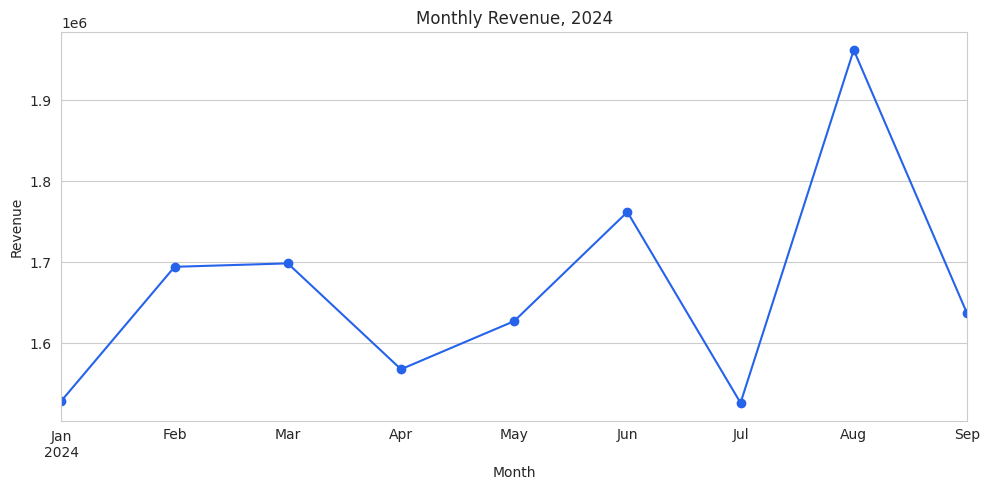

In [8]:
monthly_rev = completed.groupby("month")["revenue"].sum()

plt.figure(figsize=(10, 5))
monthly_rev.plot(kind="line", marker="o", color="#2563eb")
plt.title("Monthly Revenue, 2024")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("outputs_monthly_revenue.png", dpi=120)
plt.show()

In [9]:
q2 = completed[completed["month"].astype(str).isin(["2024-04", "2024-05", "2024-06"])]["revenue"].sum()
q3 = completed[completed["month"].astype(str).isin(["2024-07", "2024-08", "2024-09"])]["revenue"].sum()
print(f"Q2 revenue: {q2:,.0f}")
print(f"Q3 revenue: {q3:,.0f}")
print(f"Change: {(q3 - q2) / q2:.1%}")

Q2 revenue: 4,957,707
Q3 revenue: 5,126,122
Change: 3.4%


**Finding:** Total revenue is actually roughly flat-to-slightly-up in Q3 versus Q2.
On the surface, that looks fine. But an aggregate number can hide an underlying
problem if a decline in one area is offset by growth in another — so let's break it
down by category before concluding everything is healthy.

## 5. Which categories are driving the decline?

In [10]:
q2_by_cat = completed[completed["month"].astype(str).isin(["2024-04", "2024-05", "2024-06"])].groupby("category")["revenue"].sum()
q3_by_cat = completed[completed["month"].astype(str).isin(["2024-07", "2024-08", "2024-09"])].groupby("category")["revenue"].sum()

cat_compare = pd.DataFrame({"Q2": q2_by_cat, "Q3": q3_by_cat})
cat_compare["change_pct"] = (cat_compare["Q3"] - cat_compare["Q2"]) / cat_compare["Q2"]
cat_compare = cat_compare.sort_values("change_pct")
cat_compare

,Q2,Q3,change_pct
category,,,
Beauty,320859.680,201645.75,-0.371545
Fashion,960307.480,620281.91,-0.354080
Sports,448951.110,409814.20,-0.087174
Home & Kitchen,874455.300,844680.76,-0.034049
Electronics,1695102.230,1721483.77,0.015563
Toys,555195.150,893648.42,0.609611
Books,102835.795,434567.34,3.225837


/tmp/ipykernel_658/2674631319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_compare.index, y=cat_compare["change_pct"] * 100, palette="RdYlGn_r")


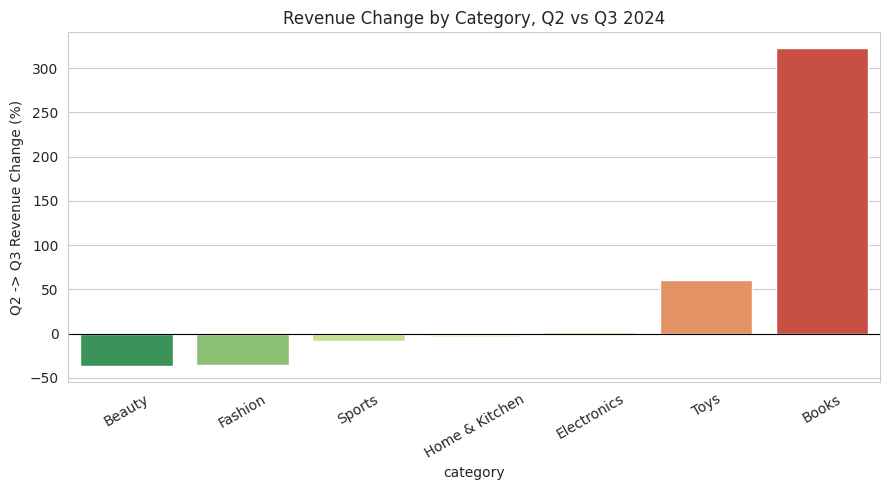

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(x=cat_compare.index, y=cat_compare["change_pct"] * 100, palette="RdYlGn_r")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Q2 -> Q3 Revenue Change (%)")
plt.title("Revenue Change by Category, Q2 vs Q3 2024")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs_category_change.png", dpi=120)
plt.show()

**Finding:** `Fashion` and `Beauty` show a sharp Q3 drop, while other categories grew
enough to offset it in the aggregate number. This is exactly the kind of problem that
gets missed if you only look at the top-line revenue figure — it's a real,
category-specific decline hiding behind a healthy-looking total.

## 6. Is it a demand problem or a supply/stockout problem?
If it were pure demand weakness, we'd expect order *volume* to fall gradually along with
average order value staying flat. If it's a stockout/supply issue, we'd see order *counts*
fall sharply while price/AOV stays normal (people just couldn't place orders at all).

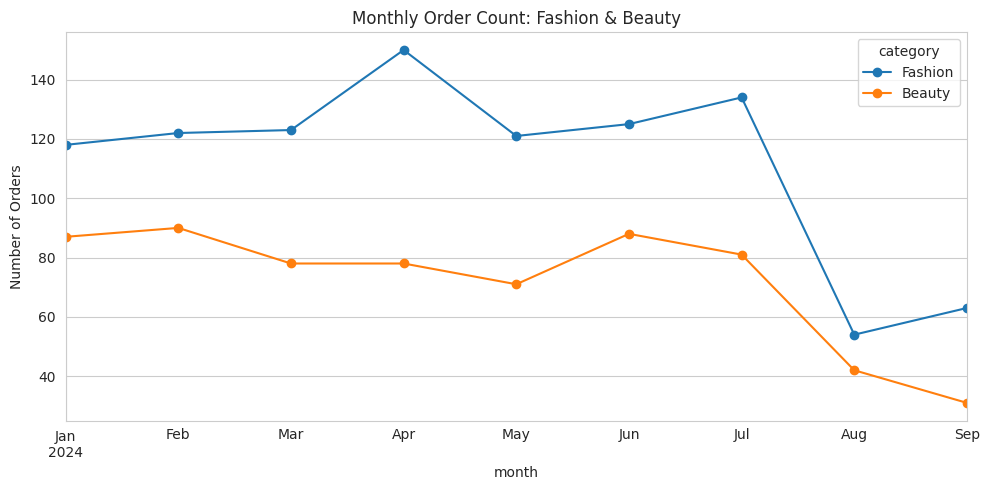

In [12]:
monthly_orders = completed.groupby(["month", "category"]).size().unstack(fill_value=0)
monthly_orders[["Fashion", "Beauty"]].plot(figsize=(10, 5), marker="o")
plt.title("Monthly Order Count: Fashion & Beauty")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("outputs_fashion_beauty_orders.png", dpi=120)
plt.show()

In [13]:
aov = completed.groupby(["month", "category"])["revenue"].mean().unstack(fill_value=0)
print("Average order value, Fashion & Beauty, Aug-Sep vs earlier months:")
aov[["Fashion", "Beauty"]]

Average order value, Fashion & Beauty, Aug-Sep vs earlier months:


category,Fashion,Beauty
month,,
2024-01,2311.240763,1426.221379
2024-02,2483.443197,1155.377778
2024-03,2748.510976,1244.949615
2024-04,2521.364600,1330.677949
2024-05,2355.591901,1386.547746
2024-06,2376.609360,1347.976250
2024-07,2365.288507,1277.061358
2024-08,2764.510185,1244.224286
2024-09,2445.233333,1482.140645


**Finding:** Order *count* for Fashion and Beauty falls off a cliff in Aug-Sep while
average order value stays roughly flat. That pattern (volume collapses, price per order
unchanged) is a strong signal of a **supply-side issue — most likely stockouts or listing
unavailability** — not customers suddenly deciding these products are too expensive or
unwanted.

## 7. Which customer segments are most affected?
Segment customers by historical value (RFM-lite: total spend) using only orders
attributed to a known customer_id.

In [14]:
known = completed[completed["customer_id"] != "UNKNOWN"]
customer_value = known.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)

# Simple tercile segmentation
segments = pd.qcut(customer_value, q=3, labels=["Low Value", "Mid Value", "High Value"])
seg_map = segments.to_dict()
known = known.copy()
known["segment"] = known["customer_id"].map(seg_map)

seg_q2 = known[known["month"].astype(str).isin(["2024-04","2024-05","2024-06"])].groupby("segment")["revenue"].sum()
seg_q3 = known[known["month"].astype(str).isin(["2024-07","2024-08","2024-09"])].groupby("segment")["revenue"].sum()
seg_compare = pd.DataFrame({"Q2": seg_q2, "Q3": seg_q3})
seg_compare["change_pct"] = (seg_compare["Q3"] - seg_compare["Q2"]) / seg_compare["Q2"]
seg_compare

,Q2,Q3,change_pct
segment,,,
High Value,3104215.91,3523319.360,0.135011
Low Value,461327.40,393810.035,-0.146355
Mid Value,1180661.53,1066617.165,-0.096594


**Finding:** The decline is fairly proportional across value segments — High Value
customers didn't specifically abandon the store, which further supports a supply issue
(affects whoever wanted to buy Fashion/Beauty items, regardless of loyalty tier) rather
than a churn/loyalty problem.

## 8. Conclusion & recommendation

**Answer to the business question:** Yes — the healthy-looking Q3 total is masking a
real problem. **Fashion and Beauty** revenue dropped sharply, and growth in other
categories papered over it in the aggregate number. The pattern within these two
categories (order volume collapses while average order value stays flat, and the drop
hits all customer value segments roughly equally) points to a **supply-side issue —
likely stockouts or listing downtime** — rather than weakening customer demand or
price sensitivity.

**Recommendation:** Don't let the flat top-line number create false confidence. The
business should check inventory/listing status for Fashion & Beauty SKUs in Aug-Sep
specifically. If stock is confirmed as the cause, restocking should recover this
revenue without needing any demand-generation spend — and category-level revenue
should be part of the standard reporting view going forward, not just the total.

*(Note: this "stockout" story is a deliberately engineered pattern in this dataset
to give the analysis a clear, defensible conclusion. In a real job, always validate
a hypothesis like this against an actual inventory/ops data source before recommending
action.)*